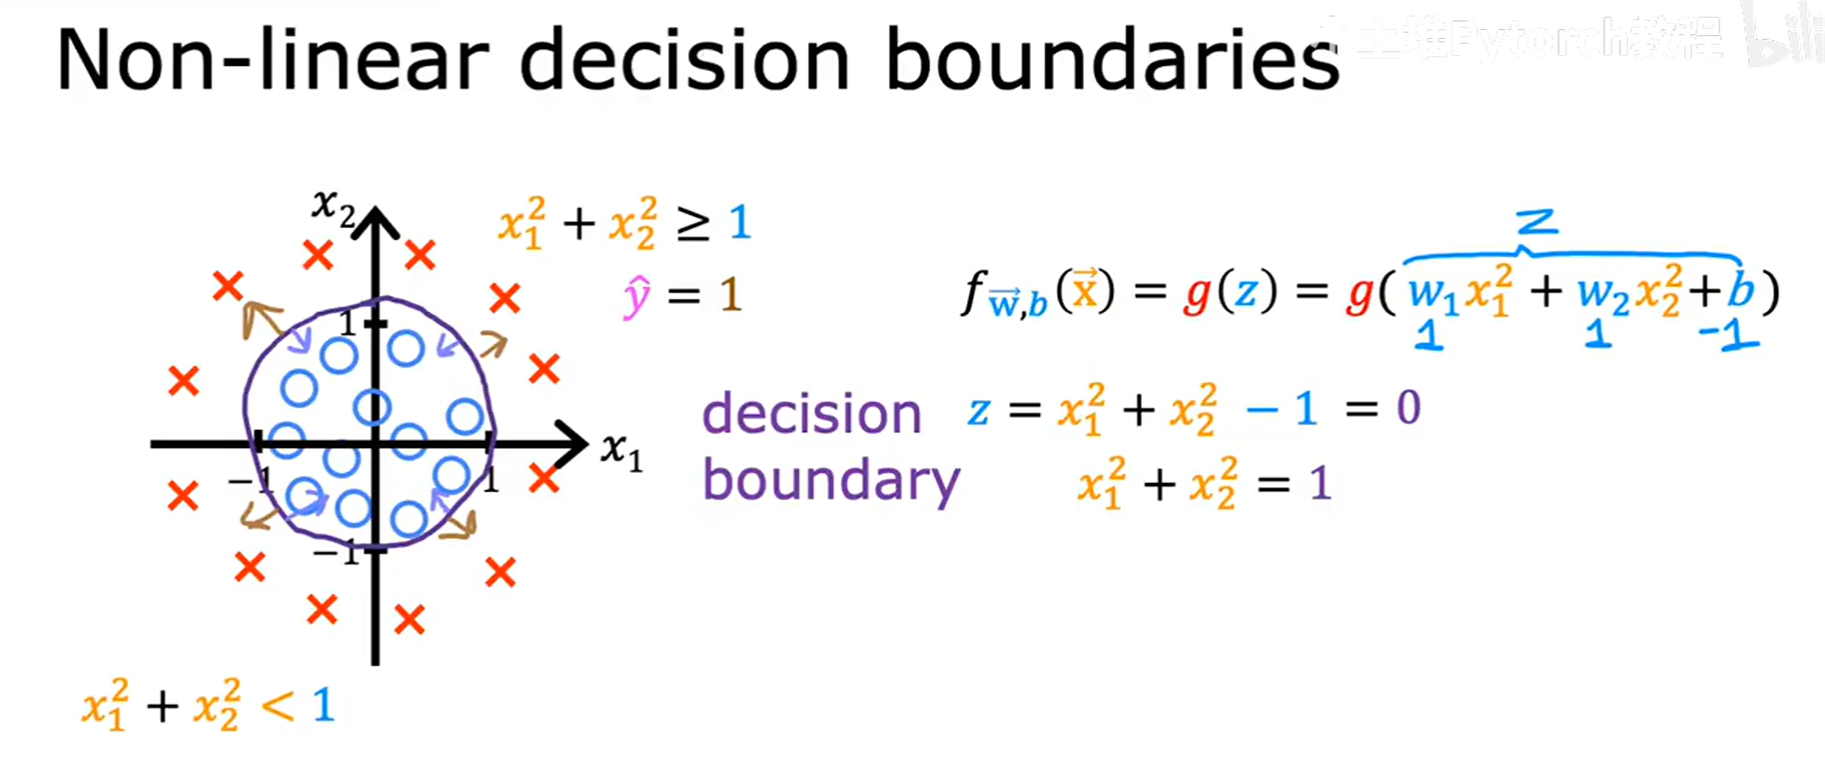

In [4]:
import torch

torch.manual_seed(0)
N = 1000
X = torch.rand(N, 2)  # 生成N个样本，每个样本是两个坐标，共同代表一个点
# torch.rand函数生成的数是[0,1),我们将其调整为[-2,2)
X = X * 4 - 2
x_train = torch.cat(
    [X[:, 0:1] ** 2, X[:, 1:2] ** 2], dim=1
)  # 这里列用0:1而不用0是因为X[:,0]取出的是一维序列，没有dim=1,而换成0:1后取出的是二维序列，和原结构一样
# bceloss要求两参数维度一致，所以这里也保留二维
y = (x_train[:, 0:1] + x_train[:, 1:2] > 1).float()


class CircleClassifier(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(torch.nn.Linear(2, 1), torch.nn.Sigmoid())

    def forward(self, x):
        return self.net(x)


classifier = CircleClassifier()
# bceloss函数要求传入float值，不只是支持硬标签0/1，也支持[0,1]之间的软标签
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(classifier.parameters(), lr=0.1)
for epoch in range(1000):
    pred = classifier(x_train)
    loss = criterion(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"epoch:{epoch}", loss.item())

epoch:0 0.44223448634147644
epoch:1 0.4226827919483185
epoch:2 0.40675613284111023
epoch:3 0.39357447624206543
epoch:4 0.38250967860221863
epoch:5 0.3731047809123993
epoch:6 0.3650207817554474
epoch:7 0.3580022156238556
epoch:8 0.35185325145721436
epoch:9 0.34642165899276733
epoch:10 0.3415878117084503
epoch:11 0.3372561037540436
epoch:12 0.3333498239517212
epoch:13 0.32980644702911377
epoch:14 0.3265748620033264
epoch:15 0.32361260056495667
epoch:16 0.3208843767642975
epoch:17 0.3183605372905731
epoch:18 0.3160160481929779
epoch:19 0.3138297200202942
epoch:20 0.3117832839488983
epoch:21 0.3098612129688263
epoch:22 0.3080500662326813
epoch:23 0.3063381612300873
epoch:24 0.3047153353691101
epoch:25 0.303172767162323
epoch:26 0.3017026484012604
epoch:27 0.30029812455177307
epoch:28 0.29895320534706116
epoch:29 0.29766252636909485
epoch:30 0.29642143845558167
epoch:31 0.2952255606651306
epoch:32 0.294071227312088
epoch:33 0.2929550111293793
epoch:34 0.29187390208244324
epoch:35 0.29082521

In [ ]:
# 手写参数版
import torch

torch.manual_seed(0)
N = 1000
X = torch.rand(N, 2)  # 生成N个样本，每个样本是两个坐标，共同代表一个点
# torch.rand函数生成的数是[0,1),我们将其调整为[-2,2)
X = X * 4 - 2

# bceloss要求两参数维度一致，所以这里也保留二维
y = (X[:, 0:1] ** 2 + X[:, 1:2] ** 2 > 1).float()


class CircleClassifier2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.w = torch.nn.Parameter(torch.rand(3))

    def forward(self, x):
        x = self.w[0] * x[:, 0:1] ** 2 + self.w[1] * x[:, 1:2] ** 2 + self.w[2]
        return torch.sigmoid(x)


classifier = CircleClassifier2()
# bceloss函数要求传入float值，不只是支持硬标签0/1，也支持[0,1]之间的软标签
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(classifier.parameters(), lr=0.1)
for epoch in range(1000):
    pred = classifier(X)
    loss = criterion(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"epoch:{epoch}", loss.item())

epoch:0 0.3207564055919647
epoch:1 0.3198643922805786
epoch:2 0.3189774751663208
epoch:3 0.31809568405151367
epoch:4 0.31721895933151245
epoch:5 0.31634727120399475
epoch:6 0.3154805898666382
epoch:7 0.3146187961101532
epoch:8 0.31376194953918457
epoch:9 0.3129100203514099
epoch:10 0.31206297874450684
epoch:11 0.31122076511383057
epoch:12 0.31038329005241394
epoch:13 0.30955058336257935
epoch:14 0.30872267484664917
epoch:15 0.3078994154930115
epoch:16 0.30708086490631104
epoch:17 0.3062669634819031
epoch:18 0.3054576516151428
epoch:19 0.3046528995037079
epoch:20 0.30385273694992065
epoch:21 0.30305710434913635
epoch:22 0.3022659420967102
epoch:23 0.3014792203903198
epoch:24 0.3006969690322876
epoch:25 0.29991909861564636
epoch:26 0.2991456389427185
epoch:27 0.29837650060653687
epoch:28 0.29761171340942383
epoch:29 0.2968512177467346
epoch:30 0.29609495401382446
epoch:31 0.29534295201301575
epoch:32 0.2945951819419861
epoch:33 0.2938516139984131
epoch:34 0.2931121289730072
epoch:35 0.29